# dataset: 노이즈_제거_에지_중복제거.xlsx

## Part 1: Page Rank (Set beta = 0.9, transport)

- global network:

In [1]:
import pandas as pd
import networkx as nx

# 1. 엑셀 데이터 로드
# xlsx 파일이므로 read_excel 사용 (engine='openpyxl' 필요)
file_path = '노이즈_제거_에지_중복제거.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# 2. 방향성 그래프(Directed Graph) 생성
# 데이터프레임의 출처/대상 컬럼을 지정하여 메모리에 그래프 적재
G = nx.from_pandas_edgelist(
    df, 
    source='출처채널', 
    target='대상채널', 
    create_using=nx.DiGraph
)

# 3. Standard PageRank 연산
# beta = 0.9 설정 (NetworkX에서는 alpha로 매핑됨)
beta_value = 0.9
pr_scores = nx.pagerank(G, alpha=beta_value)

# 4. 결과 정렬 및 출력 (상위 20개)
sorted_pr = sorted(pr_scores.items(), key=lambda item: item[1], reverse=True)

print(f"=== Standard PageRank Top 20 (beta={beta_value}) ===")
for rank, (node, score) in enumerate(sorted_pr[:20], 1):
    print(f"{rank}위. {node}: {score:.5f}")

=== Standard PageRank Top 20 (beta=0.9) ===
1위. YouTube지누: 0.03094
2위. 미녕이데려오깨: 0.02193
3위. 탬탬버린: 0.01916
4위. 다주: 0.01911
5위. 공룡: 0.01801
6위. 괴물쥐 유튜브: 0.01782
7위. 악녀: 0.01770
8위. 이오몽: 0.01703
9위. 러끼: 0.01578
10위. 채현찌: 0.01556
11위. 삼식: 0.01479
12위. 순당무: 0.01370
13위. 빅헤드: 0.01343
14위. 김뿡: 0.01335
15위. 피닉스박: 0.01322
16위. 임나은: 0.01315
17위. 장마군: 0.01278
18위. 이춘향: 0.01224
19위. 왈도쿤: 0.01197
20위. 댕균: 0.01168


### Visualization

In [ ]:
!pip install pyvis

In [3]:
from pyvis.network import Network

net = Network(height='1000px', width='100%', bgcolor='#222222', font_color='white', directed=True)

# PageRank 값에 따라 노드 크기 설정
for node, score in pr_scores.items():
    net.add_node(node, label=node, title=f"PR: {score:.5f}", value=score * 100)

# 에지 추가
for source, target in G.edges():
    net.add_edge(source, target)

# 물리 엔진 설정 및 결과 저장
net.force_atlas_2based()
net.show('PR_youtube.html', notebook=False)

PR_youtube.html


***

## Part 2: PPR (Personalized Page Rank)

- Teleport Set, $S$ ?
- 오버워치 게임 유튜버로 try.. (Local NetworK)
  - 일루전 ILLUSION
  - 아이치
  - 아론 페이지
  - 세찬 SECHAN

In [4]:
# 1. 새로운 Teleport Set (S) 설정: 실제 이미지에 있던 4명
target_channels = ['일루전 ILLUSION', '아이치', '아론 페이지', '세찬 SECHAN']

# 데이터셋에 해당 채널이 존재하는지 검증 (띄어쓰기 등 불일치 확인용)
missing_channels = [ch for ch in target_channels if ch not in G.nodes()]
if missing_channels:
    print(f"⚠️ 경고: 데이터셋에 다음 채널이 없습니다. 엑셀의 정확한 띄어쓰기를 확인해주세요: {missing_channels}")

# 2. 새로운 텔레포트 확률 분포 설정 (4명에게만 가중치 부여)
personalization_dict = {node: (1 if node in target_channels else 0) for node in G.nodes()}

# 3. Personalized PageRank 연산 (beta=0.9)
beta_value = 0.9
ppr_scores = nx.pagerank(G, alpha=beta_value, personalization=personalization_dict)

# 4. 결과 정렬 및 출력 (상위 20개)
sorted_ppr = sorted(ppr_scores.items(), key=lambda item: item[1], reverse=True)

print(f"=== 타겟(일루전, 아이치, 아론 페이지, 세찬) PPR Top 20 (beta={beta_value}) ===")
for rank, (node, score) in enumerate(sorted_ppr[:20], 1):
    print(f"{rank}위. {node}: {score:.5f}")

=== 타겟(일루전, 아이치, 아론 페이지, 세찬) PPR Top 20 (beta=0.9) ===
1위. 아이치: 0.12509
2위. 위도 W2RDØ: 0.11451
3위. 일루전 ILLUSION: 0.05831
4위. 이오몽: 0.05208
5위. 아론 페이지: 0.04505
6위. 세찬 SECHAN: 0.04484
7위. 미녕이데려오깨: 0.04005
8위. 세노: 0.03812
9위. 얍얍: 0.03461
10위. 러너: 0.02883
11위. T1 Faker: 0.02348
12위. 라디유: 0.01646
13위. 밍모: 0.01370
14위. YouTube지누: 0.01288
15위. 러끼: 0.01152
16위. 삼식: 0.01111
17위. 다주: 0.01097
18위. 괴물쥐 유튜브: 0.01049
19위. 탬탬버린: 0.01001
20위. 순당무: 0.00877


- 위도 W2RDØ
- 이오몽
- 미뇽이데려오깨
- ...

> 이 유튜버들도 잡은 $S$ 기준으로 중요한 nodes.

### Sub-Plot


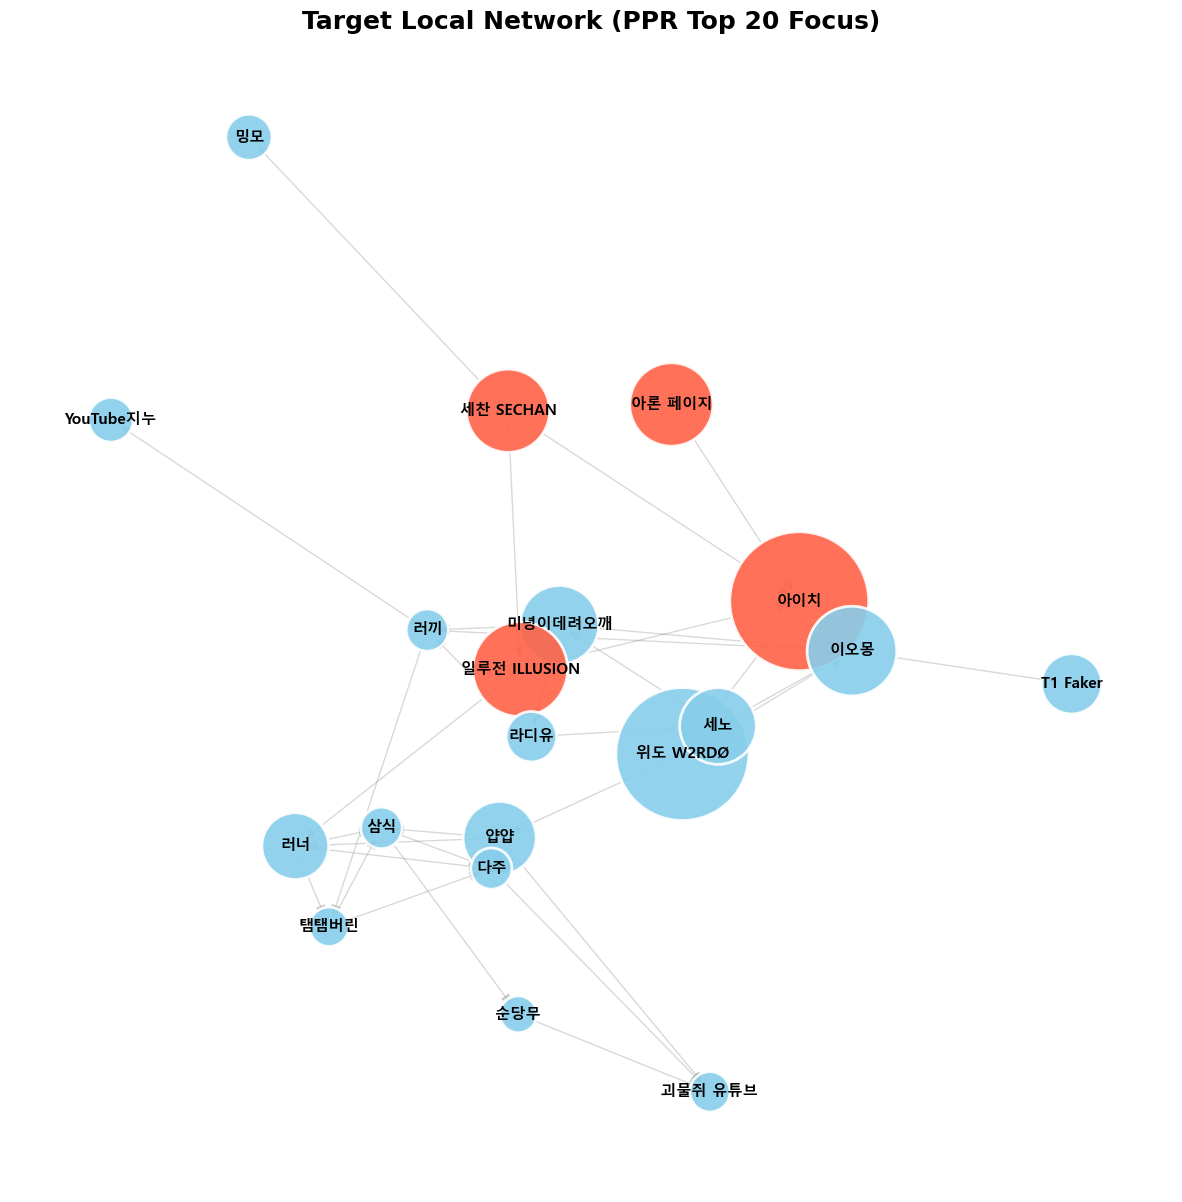

In [5]:
import matplotlib.pyplot as plt

# 1. 시각화를 위한 서브그래프 추출 (타겟 및 Top 20 노드 중심)
# PPR 상위 20개 노드를 추출
top_20_nodes = [node for node, score in sorted_ppr[:20]]

# 타겟 4명과 PPR 상위 20명으로 구성된 노드 집합
nodes_to_draw = set(target_channels + top_20_nodes)

# 해당 노드들로만 이루어진 서브그래프(Subgraph) 생성
# .copy()를 통해 뷰가 아닌 독립적인 그래프 객체로 만듭니다.
subG = G.subgraph(nodes_to_draw).copy()

# 2. 시각화를 위한 좌표 계산 (Spring Layout)
# k값을 조절하여 노드 간의 반발력을 설정합니다.
pos = nx.spring_layout(subG, k=0.5, seed=42)

# 3. 렌더링 설정
plt.figure(figsize=(15, 15))

# 노드 색상 및 크기 분리
node_colors = []
node_sizes = []

for node in subG.nodes():
    # 타겟 노드는 빨간색으로 강조
    if node in target_channels:
        node_colors.append('tomato')
        # 타겟 노드의 기본 크기 설정 (PPR이 낮더라도 잘 보이게)
        node_sizes.append(ppr_scores.get(node, 0.05) * 80000) 
    else:
        node_colors.append('skyblue')
        # 나머지 노드는 PPR 점수에 비례하게 크기 설정
        node_sizes.append(ppr_scores.get(node, 0.01) * 80000)

# 그래프 그리기
nx.draw_networkx_nodes(subG, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, edgecolors='white', linewidths=2)
# 에지 그리기 (화살표 포함)
nx.draw_networkx_edges(subG, pos, alpha=0.3, edge_color='gray', arrows=True, arrowsize=15)

# 라벨 그리기 (폰트 깨짐 방지를 위해 Malgun Gothic 등 한글 폰트 지정 필요)
nx.draw_networkx_labels(subG, pos, font_size=11, font_family='Malgun Gothic', font_weight='bold')

plt.title(f"Target Local Network (PPR Top 20 Focus)", fontsize=18, fontweight='bold')
plt.axis('off')

# 화면에 출력
plt.show()